In [1]:
# %pip install yfinance
import matplotlib.pyplot as plt
import pandas as pd
import yfinance as yf

In [2]:
# load real stock data 
# Reliance Industries Limited (RELIANCE.NS)

stock = yf.download("RELIANCE.NS",start="2025-01-01",end="2026-01-01")
stock.head()
# save the data 
# stock.to_csv("Reliance.csv")

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,
2025-01-01,1210.793579,1215.800389,1201.226179,1204.448352,5892590
2025-01-02,1231.167725,1233.794938,1209.554328,1210.793626,15486276
2025-01-03,1240.437744,1251.244443,1224.921714,1233.249818,15521102
2025-01-06,1207.571411,1251.194681,1204.597097,1243.213557,14816766
2025-01-07,1230.225708,1233.844481,1210.793549,1211.537128,10070505


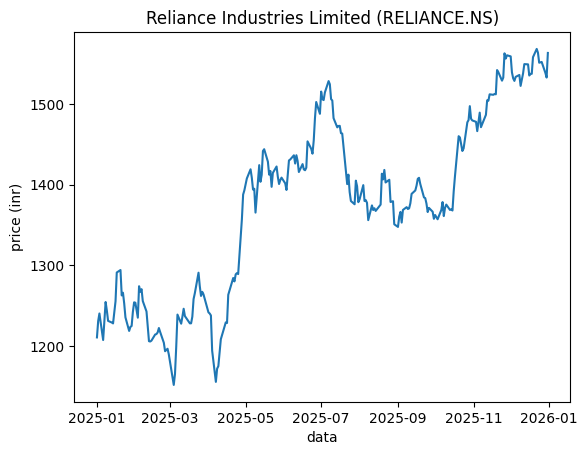

In [3]:
plt.figure()
plt.plot(stock['Close'])
plt.title("Reliance Industries Limited (RELIANCE.NS)")
plt.xlabel("data")
plt.ylabel("price (inr)")
plt.show()

In [4]:
stock['MA50'] = stock['Close'].rolling(window=50).mean()
stock['MA70'] = stock['Close'].rolling(window=70).mean()

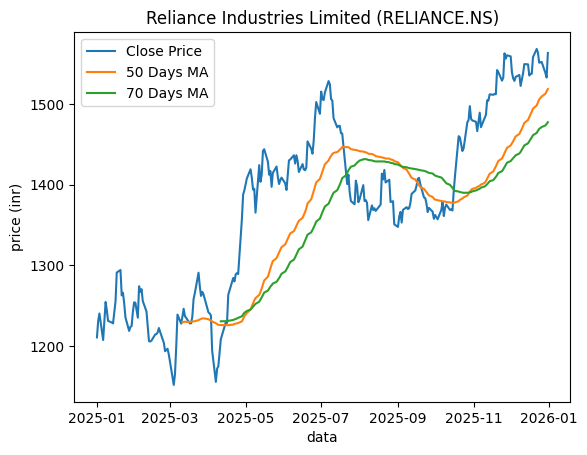

In [5]:
# stock.head()
plt.plot(stock['Close'],label='Close Price')
plt.plot(stock['MA50'],label='50 Days MA')
plt.plot(stock['MA70'],label='70 Days MA')
plt.title("Reliance Industries Limited (RELIANCE.NS)")
plt.xlabel("data")
plt.ylabel("price (inr)")
plt.legend()
plt.show()

In [6]:
stock.head()

Price,Close,High,Low,Open,Volume,MA50,MA70
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,,
Date,,,,,,,
2025-01-01,1210.793579,1215.800389,1201.226179,1204.448352,5892590,NaN,NaN
2025-01-02,1231.167725,1233.794938,1209.554328,1210.793626,15486276,NaN,NaN
2025-01-03,1240.437744,1251.244443,1224.921714,1233.249818,15521102,NaN,NaN
2025-01-06,1207.571411,1251.194681,1204.597097,1243.213557,14816766,NaN,NaN
2025-01-07,1230.225708,1233.844481,1210.793549,1211.537128,10070505,NaN,NaN


In [7]:
# bar chart Volume

stock.columns

MultiIndex([( 'Close', 'RELIANCE.NS'),
            (  'High', 'RELIANCE.NS'),
            (   'Low', 'RELIANCE.NS'),
            (  'Open', 'RELIANCE.NS'),
            ('Volume', 'RELIANCE.NS'),
            (  'MA50',            ''),
            (  'MA70',            '')],
           names=['Price', 'Ticker'])

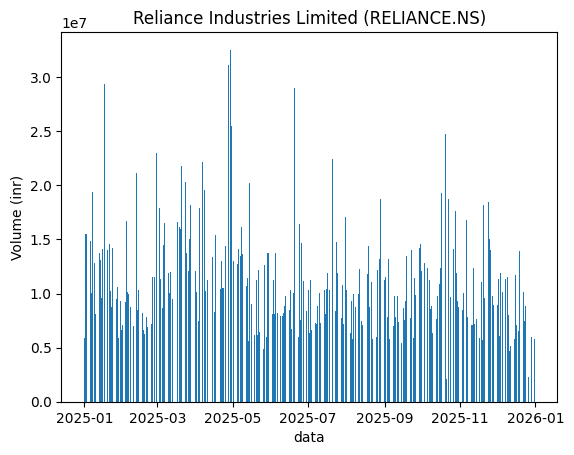

In [8]:
plt.bar(stock.index,stock['Volume']['RELIANCE.NS'])
plt.title("Reliance Industries Limited (RELIANCE.NS)")
plt.xlabel("data")
plt.ylabel("Volume (inr)")
plt.show()

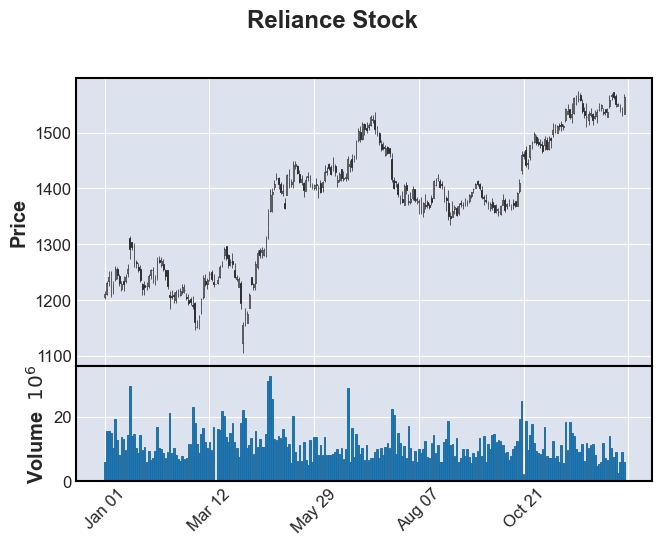

In [9]:
# candlestick chart 
# %pip install mplfinance

import mplfinance as mpf

stock.columns = stock.columns.droplevel(1)

# convert to float
stock = stock.astype(float)

# plot
mpf.plot(stock,type='candle',volume=True,title='Reliance Stock')

[*********************100%***********************]  1 of 2 completed
[*********************100%***********************]  1 of 2 completed

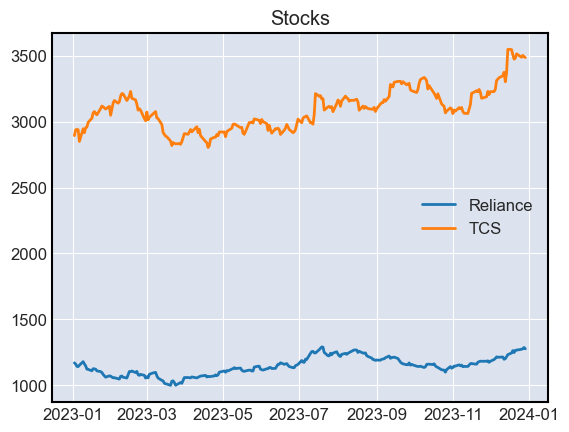

In [10]:
stocks = yf.download(["RELIANCE.NS","TCS.NS"],start="2023-01-01",end="2024-01-01")

plt.plot(stocks['Close']['RELIANCE.NS'],label="Reliance")
plt.plot(stocks['Close']['TCS.NS'],label="TCS")
plt.legend()
plt.title("Stocks")
plt.show()

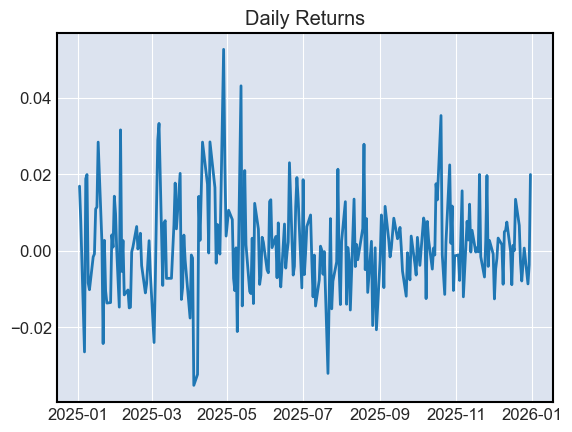

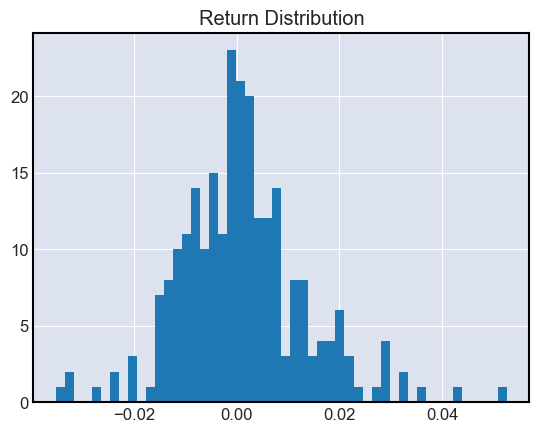

In [12]:
# daily return 
stock['Daily Return'] = stock['Close'].pct_change()
plt.plot(stock['Daily Return'])
plt.title("Daily Returns")
plt.show()

# histogram Risk analysis
plt.hist(stock['Daily Return'].dropna(),bins=50)
plt.title("Return Distribution")
plt.show()